In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
lc   = pd.read_csv('learning_curve.csv')
obs  = pd.read_csv('obs_prediction.csv')
eval = pd.read_csv('obs_predict_model_eval.csv')

In [9]:
print("Model evaluation metrics")
print("-" * 35)
for _, row in eval.iterrows():
    print(f"{row['output']:>10s}  MSE = {row['mse']:.6g}  R² = {row['r_squared']:.6g}")

Model evaluation metrics
-----------------------------------
       ImH  MSE = 0.00103281  R² = 0.0982226


## Training and validation loss

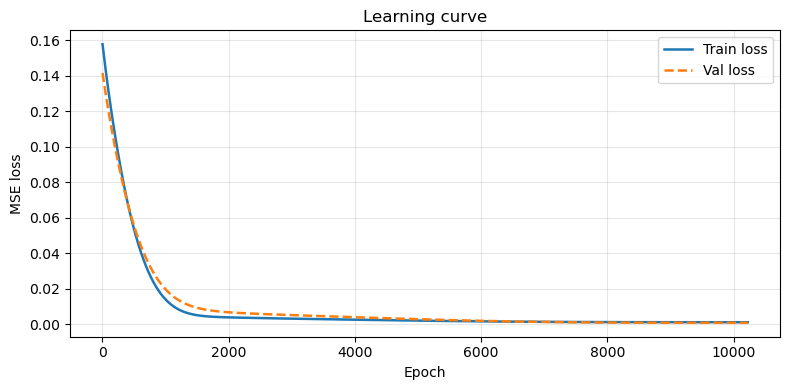

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(lc['epoch'], lc['train_loss'], label='Train loss', linewidth=1.8)
ax.plot(lc['epoch'], lc['val_loss'],   label='Val loss',   linewidth=1.8, linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Learning curve')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Residuals: $y_\mathrm{true} - y_\mathrm{pred}$ vs row

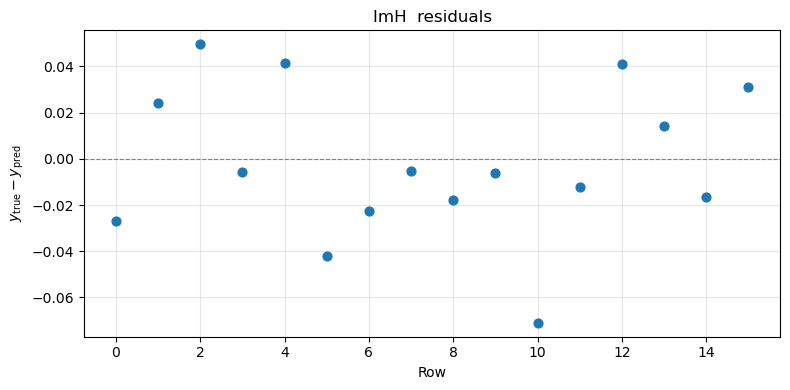

In [11]:
true_cols    = [c for c in obs.columns if c.endswith('_true')]
pred_cols    = [c for c in obs.columns if c.endswith('_pred')]
output_names = [c.replace('_true', '') for c in true_cols]

n_outputs = len(output_names)
fig, axes = plt.subplots(n_outputs, 1, figsize=(8, 4 * n_outputs), squeeze=False)

for i, (name, tc, pc) in enumerate(zip(output_names, true_cols, pred_cols)):
    residuals = obs[tc] - obs[pc]
    ax = axes[i, 0]
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.scatter(obs.index, residuals, s=40, zorder=3)
    ax.set_xlabel('Row')
    ax.set_ylabel(r'$y_{\mathrm{true}} - y_{\mathrm{pred}}$')
    ax.set_title(f'{name}  residuals')
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Residuals: $y_\mathrm{true} - y_\mathrm{pred}$ vs $y_\mathrm{true}$

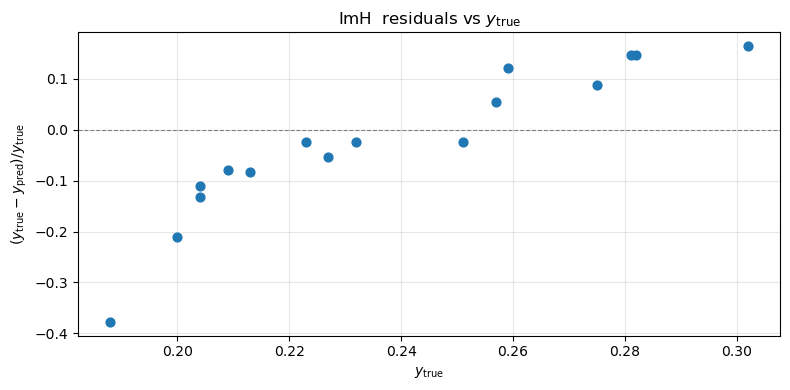

In [12]:
true_cols    = [c for c in obs.columns if c.endswith('_true')]
pred_cols    = [c for c in obs.columns if c.endswith('_pred')]
output_names = [c.replace('_true', '') for c in true_cols]

n_outputs = len(output_names)
fig, axes = plt.subplots(n_outputs, 1, figsize=(8, 4 * n_outputs), squeeze=False)

for i, (name, tc, pc) in enumerate(zip(output_names, true_cols, pred_cols)):
    residuals = (obs[tc] - obs[pc])/obs[tc] 
    ax = axes[i, 0]
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.scatter(obs[tc], residuals, s=40, zorder=3)
    ax.set_xlabel(r'$y_{\mathrm{true}}$')
    ax.set_ylabel(r'$(y_{\mathrm{true}} - y_{\mathrm{pred}}) / y_{\mathrm{true}}$')
    ax.set_title(f'{name}  residuals vs $y_{{\\mathrm{{true}}}}$')
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()